In [7]:
import pandas as pd



In [11]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
display(df.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [ ]:
# Inspect
print(df.shape)  # Expected: (7043, 21)
print(df.head())
print(df.info())
print(df.isnull().sum())
print(df['Churn'].value_counts())  # Target distribution

(7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Co

In [ ]:
# Extract columns 5 and 15 (0-indexed: columns 4 and 14)
col_5_15 = df.iloc[:, [4, 14]]
print("Columns 5 & 15:")
print(col_5_15.head())

Columns 5 & 15:
  Dependents StreamingMovies
0         No              No
1         No              No
2         No              No
3         No              No
4         No              No


In [ ]:
# Assuming columns: 'SeniorCitizen' (0/1), 'gender' (Male/Female), 'PaymentMethod'
senior_male_electronic = df[
    (df['SeniorCitizen'] == 1) &
    (df['gender'] == 'Male') &
    (df['PaymentMethod'] == 'Electronic check')
]
print(f"Senior males with electronic check: {len(senior_male_electronic)}")

Senior males with electronic check: 298


In [ ]:
### 2.3 Filter: Customer Total Tenure (tenure > 70 OR MonthlyCharges > $100)

customer_total_tenure = df[
    (df['tenure'] > 70) |
    (df['MonthlyCharges'] > 100)
]
print(f"Customers with tenure > 70 or charges > $100: {len(customer_total_tenure)}")

Customers with tenure > 70 or charges > $100: 1259


In [ ]:
### 2.4 Filter: Two Mail Yes (likely internet service + online security)

# Adjust based on actual column names in your dataset
two_mail_yes = df[
    (df['InternetService'] != 'No') &
    (df['OnlineSecurity'] == 'Yes')
]
print(f"Customers with internet service and online security: {len(two_mail_yes)}")

Customers with internet service and online security: 2019


In [ ]:
### 2.5 Random sample of 333 records

customer_333 = df.sample(n=333, random_state=42)
print(f"Random sample: {len(customer_333)}")


Random sample: 333


In [ ]:

### 2.6 Churn value counts (full dataset)

churn_counts = df['Churn'].value_counts()
print("Churn distribution:")
print(churn_counts)

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [ ]:
## STEP 3: Exploratory Data Analysis (EDA)

### 3.1 Convert target to binary (Yes=1, No=0)

df['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)

In [ ]:
### 3.2 Data type conversions

# Identify and encode categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('Churn')  # Keep Churn as is for now

print(f"Categorical columns: {categorical_cols}")

Categorical columns: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges']


In [ ]:
label_encoders = {}
df_encoded = df.copy()

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df[col])
    label_encoders[col] = le

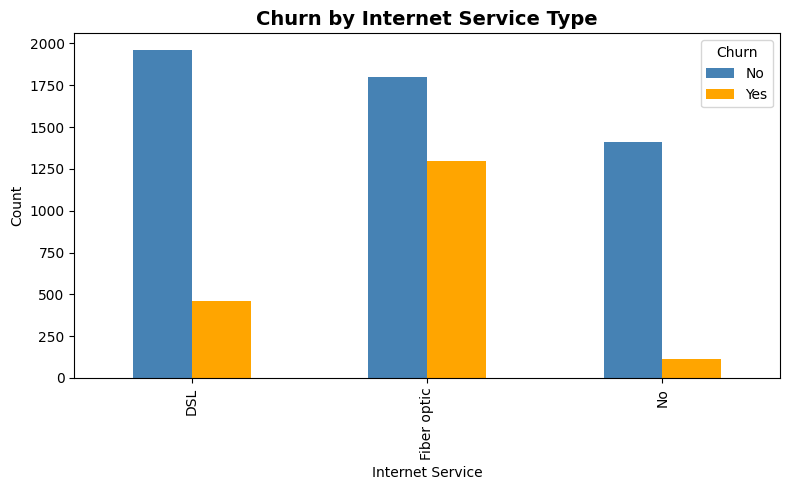

In [ ]:
### 3.3 Visualization 1: Bar plot — InternetService (orange)

fig, ax = plt.subplots(figsize=(8, 5))
internet_churn = df.groupby(['InternetService', 'Churn']).size().unstack()
internet_churn.plot(kind='bar', ax=ax, color=['steelblue', 'orange'])
ax.set_title('Churn by Internet Service Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Internet Service')
ax.set_ylabel('Count')
ax.legend(title='Churn')
plt.tight_layout()
plt.savefig('01_internet_service_churn.png', dpi=300, bbox_inches='tight')
plt.show()

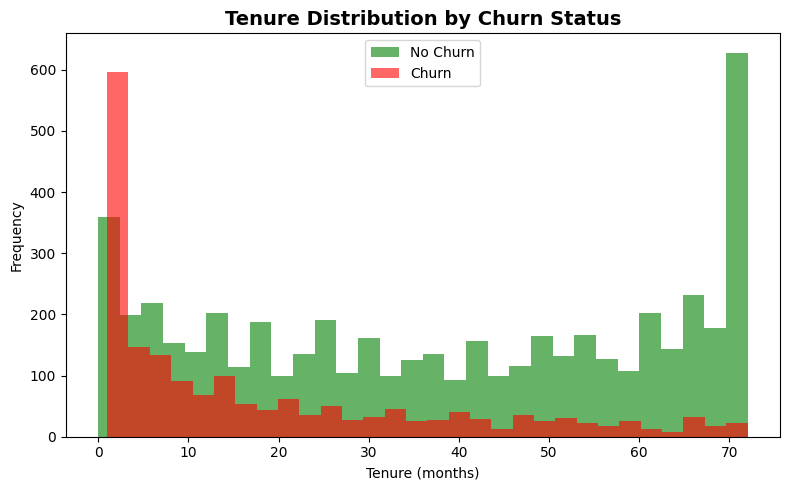

In [ ]:
### 3.4 Visualization 2: Histogram — Tenure (green, 30 bins)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df[df['Churn'] == 'No']['tenure'], bins=30, alpha=0.6, label='No Churn', color='green')
ax.hist(df[df['Churn'] == 'Yes']['tenure'], bins=30, alpha=0.6, label='Churn', color='red')
ax.set_title('Tenure Distribution by Churn Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig('02_tenure_histogram.png', dpi=300, bbox_inches='tight')
plt.show()

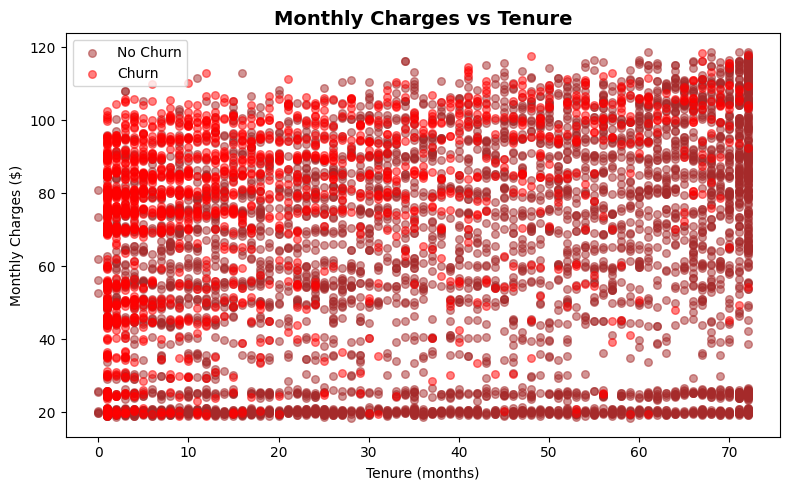

In [12]:
### 3.5 Visualization 3: Scatter — MonthlyCharges vs Tenure (brown)
fig, ax = plt.subplots(figsize=(8, 5))
for churn_val, color, label in [('No', 'brown', 'No Churn'), ('Yes', 'red', 'Churn')]:
    subset = df[df['Churn'] == churn_val]
    ax.scatter(subset['tenure'], subset['MonthlyCharges'], alpha=0.5, s=30,
               color=color, label=label)
ax.set_title('Monthly Charges vs Tenure', fontsize=14, fontweight='bold')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Monthly Charges ($)')
ax.legend()
plt.tight_layout()
plt.savefig('03_charges_vs_tenure_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

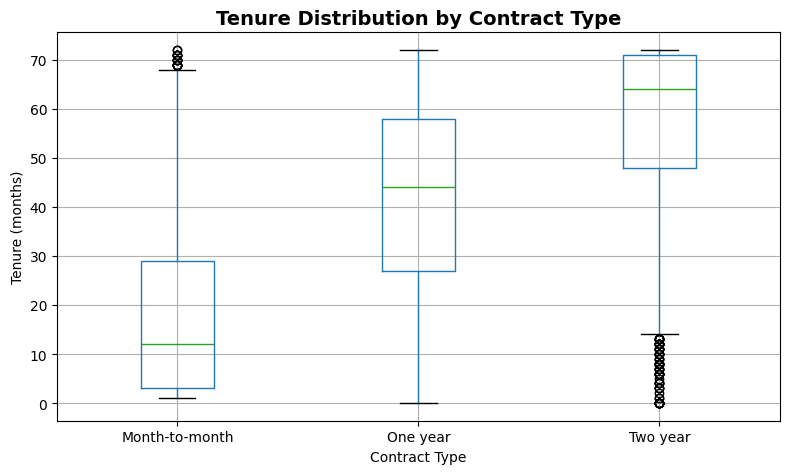

In [14]:
### 3.6 Visualization 4: Box plot — Tenure vs Contract

fig, ax = plt.subplots(figsize=(8, 5))
df.boxplot(column='tenure', by='Contract', ax=ax)
ax.set_title('Tenure Distribution by Contract Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Contract Type')
ax.set_ylabel('Tenure (months)')
plt.suptitle('')  # Remove auto title
plt.tight_layout()
plt.savefig('04_tenure_by_contract_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()


In [17]:
### 3.7 Statistical summary

# Ensure Churn_binary exists
if 'Churn_binary' not in df.columns:
    df['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)

# Ensure TotalCharges is numeric for correlation analysis
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("=== STATISTICAL SUMMARY ===")
print("\nChurn rate by Internet Service:")
print(df.groupby('InternetService')['Churn_binary'].agg(['count', 'sum', 'mean']))

print("\nAverage tenure by Churn status:")
print(df.groupby('Churn')['tenure'].describe())

print("\nAverage monthly charges by Churn status:")
print(df.groupby('Churn')['MonthlyCharges'].describe())

print("\nCorrelation between tenure, charges, and churn:")
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
print(df[numeric_cols + ['Churn_binary']].corr()['Churn_binary'].sort_values(ascending=False))

=== STATISTICAL SUMMARY ===

Churn rate by Internet Service:
                 count   sum      mean
InternetService                       
DSL               2421   459  0.189591
Fiber optic       3096  1297  0.418928
No                1526   113  0.074050

Average tenure by Churn status:
        count       mean        std  min   25%   50%   75%   max
Churn                                                           
No     5174.0  37.569965  24.113777  0.0  15.0  38.0  61.0  72.0
Yes    1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0

Average monthly charges by Churn status:
        count       mean        std    min    25%     50%   75%     max
Churn                                                                  
No     5174.0  61.265124  31.092648  18.25  25.10  64.425  88.4  118.75
Yes    1869.0  74.441332  24.666053  18.85  56.15  79.650  94.2  118.35

Correlation between tenure, charges, and churn:
Churn_binary      1.000000
MonthlyCharges    0.193356
TotalCharges     -

## STEP 4: Model 1 — Linear Regression (MonthlyCharges ~ Tenure)

In [18]:
### 4.1 Prepare data

# Simple model: MonthlyCharges ~ tenure
X_lr = df[['tenure']].values
y_lr = df['MonthlyCharges'].values

# 70:30 split
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_lr, test_size=0.3, random_state=42
)

print(f"Train: {len(X_train_lr)}, Test: {len(X_test_lr)}")

Train: 4930, Test: 2113


In [19]:
### 4.2 Train & evaluate

# Train
lr_model = LinearRegression()
lr_model.fit(X_train_lr, y_train_lr)

# Predict
y_pred_lr = lr_model.predict(X_test_lr)

# Evaluate
rmse_lr = np.sqrt(mean_squared_error(y_test_lr, y_pred_lr))
print(f"\n=== LINEAR REGRESSION ===")
print(f"Equation: MonthlyCharges = {lr_model.intercept_:.2f} + {lr_model.coef_[0]:.4f} * tenure")
print(f"RMSE: {rmse_lr:.2f}")
print(f"R-squared: {lr_model.score(X_test_lr, y_test_lr):.4f}")



=== LINEAR REGRESSION ===
Equation: MonthlyCharges = 54.80 + 0.3082 * tenure
RMSE: 29.08
R-squared: 0.0586


## STEP 5: Model 2 — Logistic Regression (Simple & Multiple)

In [20]:
### 5.1 Simple model (Churn ~ MonthlyCharges, 65:35 split)

# Prepare: MonthlyCharges only
X_log_simple = df[['MonthlyCharges']].values
y_log = df['Churn_binary'].values

X_train_ls, X_test_ls, y_train_ls, y_test_ls = train_test_split(
    X_log_simple, y_log, test_size=0.35, random_state=42
)

# Train
log_model_simple = LogisticRegression(random_state=42, max_iter=1000)
log_model_simple.fit(X_train_ls, y_train_ls)

# Evaluate
y_pred_ls = log_model_simple.predict(X_test_ls)
acc_ls = accuracy_score(y_test_ls, y_pred_ls)
cm_ls = confusion_matrix(y_test_ls, y_pred_ls)

print(f"\n=== LOGISTIC REGRESSION (SIMPLE) ===")
print(f"Features: MonthlyCharges")
print(f"Train size: {len(X_train_ls)}, Test size: {len(X_test_ls)}")
print(f"Accuracy: {acc_ls:.4f}")
print(f"Confusion Matrix:\n{cm_ls}")
print(f"Precision: {precision_score(y_test_ls, y_pred_ls):.4f}")
print(f"Recall: {recall_score(y_test_ls, y_pred_ls):.4f}")
print(f"F1-Score: {f1_score(y_test_ls, y_pred_ls):.4f}")



=== LOGISTIC REGRESSION (SIMPLE) ===
Features: MonthlyCharges
Train size: 4577, Test size: 2466
Accuracy: 0.7287
Confusion Matrix:
[[1797    0]
 [ 669    0]]
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000


In [22]:
### 5.2 Multiple model (Churn ~ tenure + MonthlyCharges, 80:20 split)

# Prepare: tenure + MonthlyCharges
X_log_multi = df[['tenure', 'MonthlyCharges']].values
y_log = df['Churn_binary'].values

X_train_lm, X_test_lm, y_train_lm, y_test_lm = train_test_split(
    X_log_multi, y_log, test_size=0.20, random_state=42
)

# Train
log_model_multi = LogisticRegression(random_state=42, max_iter=1000)
log_model_multi.fit(X_train_lm, y_train_lm)

# Evaluate
y_pred_lm = log_model_multi.predict(X_test_lm)
acc_lm = accuracy_score(y_test_lm, y_pred_lm)
cm_lm = confusion_matrix(y_test_lm, y_pred_lm)

print(f"\n=== LOGISTIC REGRESSION (MULTIPLE) ===")
print(f"Features: tenure, MonthlyCharges")
print(f"Train size: {len(X_train_lm)}, Test size: {len(X_test_lm)}")
print(f"Accuracy: {acc_lm:.4f}")
print(f"Confusion Matrix:\n{cm_lm}")
print(f"Precision: {precision_score(y_test_lm, y_pred_lm):.4f}")
print(f"Recall: {recall_score(y_test_lm, y_pred_lm):.4f}")
print(f"F1-Score: {f1_score(y_test_lm, y_pred_lm):.4f}")


=== LOGISTIC REGRESSION (MULTIPLE) ===
Features: tenure, MonthlyCharges
Train size: 5634, Test size: 1409
Accuracy: 0.7977
Confusion Matrix:
[[944  92]
 [193 180]]
Precision: 0.6618
Recall: 0.4826
F1-Score: 0.5581



## STEP 6: Model 3 — Decision Tree (Churn ~ Tenure, 80:20)

In [23]:
X_dt = df[['tenure']].values
y_dt = df['Churn_binary'].values

X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(
    X_dt, y_dt, test_size=0.20, random_state=42
)

# Train
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train_dt, y_train_dt)

# Evaluate
y_pred_dt = dt_model.predict(X_test_dt)
acc_dt = accuracy_score(y_test_dt, y_pred_dt)
cm_dt = confusion_matrix(y_test_dt, y_pred_dt)

print(f"\n=== DECISION TREE ===")
print(f"Features: tenure")
print(f"Train size: {len(X_train_dt)}, Test size: {len(X_test_dt)}")
print(f"Accuracy: {acc_dt:.4f}")
print(f"Confusion Matrix:\n{cm_dt}")
print(f"Precision: {precision_score(y_test_dt, y_pred_dt):.4f}")
print(f"Recall: {recall_score(y_test_dt, y_pred_dt):.4f}")
print(f"F1-Score: {f1_score(y_test_dt, y_pred_dt):.4f}")


=== DECISION TREE ===
Features: tenure
Train size: 5634, Test size: 1409
Accuracy: 0.7573
Confusion Matrix:
[[951  85]
 [257 116]]
Precision: 0.5771
Recall: 0.3110
F1-Score: 0.4042


## STEP 7: Model 4 — Random Forest (Churn ~ Tenure + MonthlyCharges, 70:30)

In [24]:
X_rf = df[['tenure', 'MonthlyCharges']].values
y_rf = df['Churn_binary'].values

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf, y_rf, test_size=0.30, random_state=42
)

# Train
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train_rf, y_train_rf)

# Evaluate
y_pred_rf = rf_model.predict(X_test_rf)
acc_rf = accuracy_score(y_test_rf, y_pred_rf)
cm_rf = confusion_matrix(y_test_rf, y_pred_rf)

print(f"\n=== RANDOM FOREST ===")
print(f"Features: tenure, MonthlyCharges")
print(f"Train size: {len(X_train_rf)}, Test size: {len(X_test_rf)}")
print(f"Accuracy: {acc_rf:.4f}")
print(f"Confusion Matrix:\n{cm_rf}")
print(f"Precision: {precision_score(y_test_rf, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test_rf, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test_rf, y_pred_rf):.4f}")

# Feature importance
print(f"\nFeature Importance:")
for feat, imp in zip(['tenure', 'MonthlyCharges'], rf_model.feature_importances_):
    print(f"  {feat}: {imp:.4f}")


=== RANDOM FOREST ===
Features: tenure, MonthlyCharges
Train size: 4930, Test size: 2113
Accuracy: 0.7851
Confusion Matrix:
[[1407  132]
 [ 322  252]]
Precision: 0.6562
Recall: 0.4390
F1-Score: 0.5261

Feature Importance:
  tenure: 0.4477
  MonthlyCharges: 0.5523


## STEP 8: Model Comparison

In [25]:
# Summary table
results = {
    'Model': ['Linear Regression', 'Logistic (Simple)', 'Logistic (Multiple)', 'Decision Tree', 'Random Forest'],
    'Accuracy': ['-', f'{acc_ls:.4f}', f'{acc_lm:.4f}', f'{acc_dt:.4f}', f'{acc_rf:.4f}'],
    'Precision': ['-', f'{precision_score(y_test_ls, y_pred_ls):.4f}',
                  f'{precision_score(y_test_lm, y_pred_lm):.4f}',
                  f'{precision_score(y_test_dt, y_pred_dt):.4f}',
                  f'{precision_score(y_test_rf, y_pred_rf):.4f}'],
    'Recall': ['-', f'{recall_score(y_test_ls, y_pred_ls):.4f}',
               f'{recall_score(y_test_lm, y_pred_lm):.4f}',
               f'{recall_score(y_test_dt, y_pred_dt):.4f}',
               f'{recall_score(y_test_rf, y_pred_rf):.4f}'],
    'F1-Score': ['-', f'{f1_score(y_test_ls, y_pred_ls):.4f}',
                 f'{f1_score(y_test_lm, y_pred_lm):.4f}',
                 f'{f1_score(y_test_dt, y_pred_dt):.4f}',
                 f'{f1_score(y_test_rf, y_pred_rf):.4f}']
}

results_df = pd.DataFrame(results)
print("\n=== MODEL COMPARISON ===")
print(results_df.to_string(index=False))

# Save for Power BI
results_df.to_csv('model_comparison.csv', index=False)


=== MODEL COMPARISON ===
              Model Accuracy Precision Recall F1-Score
  Linear Regression        -         -      -        -
  Logistic (Simple)   0.7287    0.0000 0.0000   0.0000
Logistic (Multiple)   0.7977    0.6618 0.4826   0.5581
      Decision Tree   0.7573    0.5771 0.3110   0.4042
      Random Forest   0.7851    0.6562 0.4390   0.5261


## STEP 9: Power BI Dashboard Structure

In [26]:
## 9.1 Prepare data for Power BI

# Export cleaned dataset with churn predictions for BI dashboard
df_bi = df.copy()
df_bi['predicted_churn'] = rf_model.predict(df[['tenure', 'MonthlyCharges']].values)

# Add segments
df_bi['Tenure_Segment'] = pd.cut(df_bi['tenure'], bins=[0, 12, 24, 60, 72],
                                   labels=['0-12 months', '12-24 months', '24-60 months', '60+ months'])
df_bi['Charges_Segment'] = pd.cut(df_bi['MonthlyCharges'], bins=[0, 50, 80, 150],
                                    labels=['Low ($0-50)', 'Medium ($50-80)', 'High ($80+)'])

# Export
df_bi.to_csv('telco_churn_for_powerbi.csv', index=False)

# Summary tables for BI
print("Data exported for Power BI:")
print(f"  - telco_churn_for_powerbi.csv ({len(df_bi)} rows)")

Data exported for Power BI:
  - telco_churn_for_powerbi.csv (7043 rows)
